In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


# ==================== Load Dataset ====================
# Example dataset (replace with your dataset)
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)


# Assume 'medv' is the target (house price)
X = df.drop('medv', axis=1)
y = df['medv']

Q1: Which features most influence price?

In [ ]:
correlation = df.corr()['medv'].sort_values(ascending=False)
print("Feature correlation with price:\n", correlation)

Feature correlation with price:
 medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


Q2: Preprocessing

In [ ]:
# Handling missing values
print("Missing values per column:\n", df.isnull().sum())


# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Missing values per column:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


Q3: RMSE and R²

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 4.928602182665336
R² Score: 0.668759493535632


Q4: Multicollinearity

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print("VIF Data:\n", vif_data)

VIF Data:
     feature       VIF
0      crim  1.792192
1        zn  2.298758
2     indus  3.991596
3      chas  1.073995
4       nox  4.393720
5        rm  1.933744
6       age  3.100826
7       dis  3.955945
8       rad  7.484496
9       tax  9.008554
10  ptratio  1.799084
11        b  1.348521
12    lstat  2.941491


Q5: Polynomial Regression

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)
model_poly = LinearRegression().fit(X_poly, y)
y_poly_pred = model_poly.predict(X_poly)


print("Polynomial Regression R²:", r2_score(y, y_poly_pred))

Polynomial Regression R²: 0.9289961714593018


Q6: Effect of Location

In [ ]:
# If dataset has 'location', use groupby; here example with 'chas' variable
print(df.groupby('chas')['medv'].mean())

chas
0    22.093843
1    28.440000
Name: medv, dtype: float64


Q7: Impact of Outliers

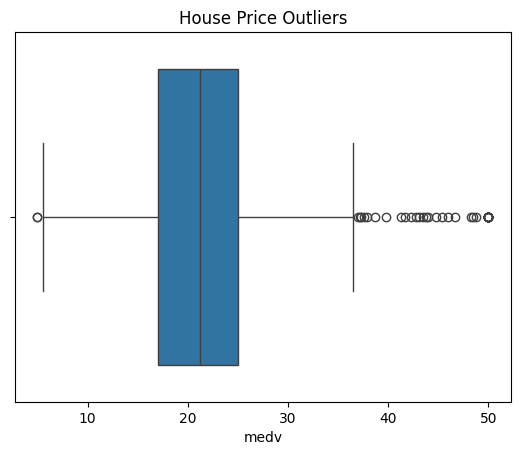

In [ ]:
sns.boxplot(x=df['medv'])
plt.title("House Price Outliers")
plt.show()

Q8: Visualize Feature Importance

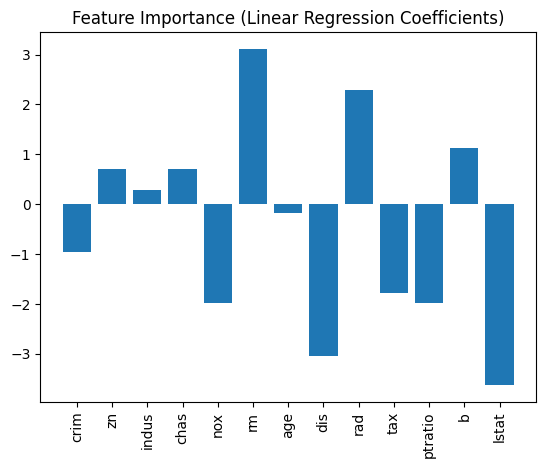

In [ ]:
importance = model.coef_
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

Q9: Assumptions of Linear Regression

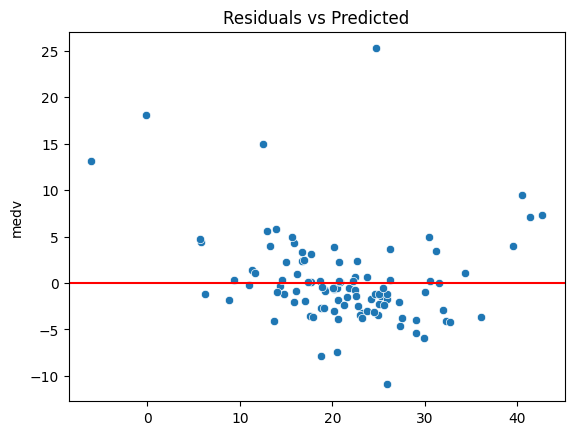

In [ ]:
# Residual plot for homoscedasticity
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

Q10: Deploy the model

In [ ]:
import pickle
pickle.dump(model, open("house_price_model.pkl", "wb"))
print("Model saved as house_price_model.pkl")

Model saved as house_price_model.pkl


Extra Q11: Handle Missing Values

In [ ]:
df.fillna(df.mean(), inplace=True)

Extra Q12: Check Normality

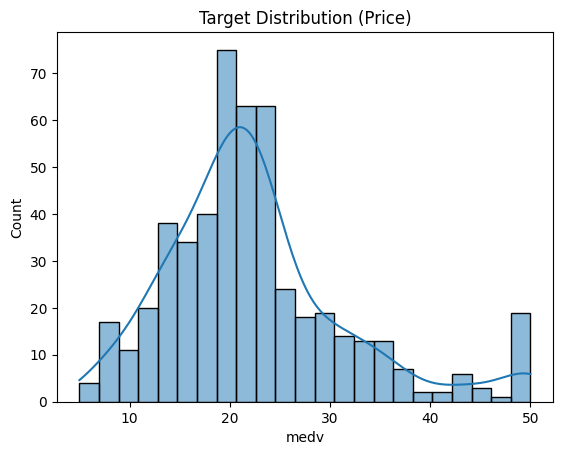

In [ ]:
sns.histplot(y, kde=True)
plt.title("Target Distribution (Price)")
plt.show()

Extra Q13: Heteroscedasticity

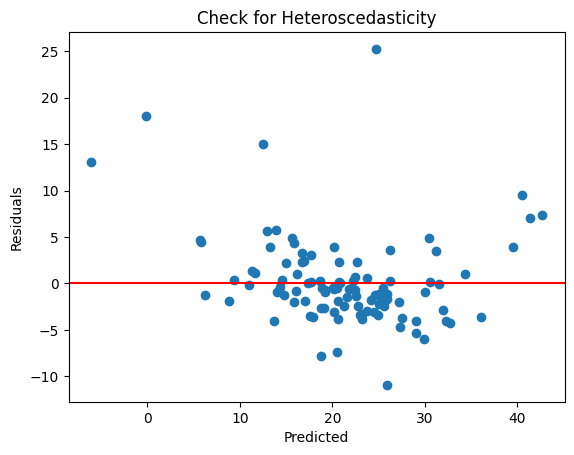

In [ ]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Check for Heteroscedasticity")
plt.show()

Extra Q14: Regularization

In [ ]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
print("Ridge R²:", ridge.score(X_test, y_test))
print("Lasso R²:", lasso.score(X_test, y_test))

Ridge R²: 0.6684401592810273
Lasso R²: 0.6497587169007897


Extra Q15: Cross-validation

In [ ]:
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("Cross-validation R² Scores:", scores)
print("Mean CV Score:", scores.mean())

Cross-validation R² Scores: [ 0.63919994  0.71386698  0.58702344  0.07923081 -0.25294154]
Mean CV Score: 0.35327592439588207
